Estimated perimeter: 650.14 ± 20.49
25.494239500996354


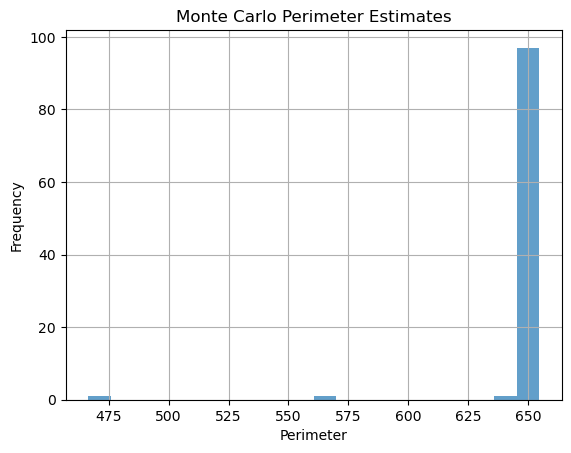

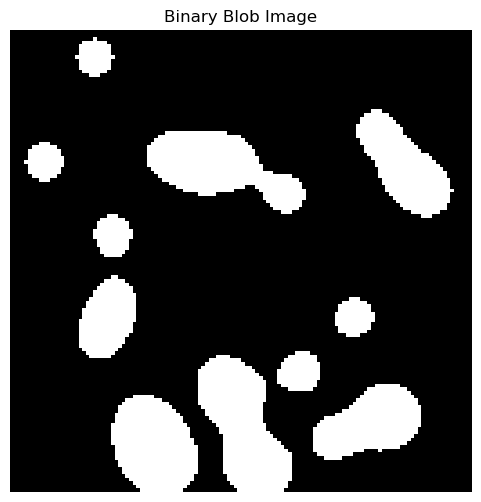

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import perimeter_crofton
from scipy.ndimage import shift
from skimage.util import random_noise

def monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8):
    """
    Estimate perimeter uncertainty via Monte Carlo simulation.

    Parameters:
        image (2D array): Binary image.
        n_iter (int): Number of perturbation samples.
        perturb (str): Type of perturbation: 'shift', 'noise', or 'shift+noise'.
        directions (int): Number of directions for Crofton perimeter (4 or 8).
        
    Returns:
        mean_perimeter (float)
        std_perimeter (float)
        all_perimeters (array)
    """
    perimeters = []
    for _ in range(n_iter):
        perturbed = image.copy()

        # Subpixel shift
        if 'shift' in perturb:
            dx, dy = np.random.uniform(-0.5, 0.5, size=2)
            perturbed = shift(perturbed, shift=(dy, dx), order=1, mode='nearest')

        # Add small Gaussian noise + threshold
        if 'noise' in perturb:
            noisy = random_noise(perturbed, mode='gaussian', var=0.001)
            perturbed = (noisy > 0.5).astype(float)

        # Compute perimeter
        p = perimeter_crofton(perturbed, directions=directions)
        perimeters.append(p)

    perimeters = np.array(perimeters)
    mean_p = np.mean(perimeters)
    std_p = np.std(perimeters)

    return mean_p, std_p, perimeters

# Example usage
if __name__ == "__main__":
    from skimage.data import binary_blobs
    image = binary_blobs(length=128, blob_size_fraction=0.2, volume_fraction=0.2)

    mean_p, std_p, perim_samples = monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(np.average(np.sqrt((perim_samples)))) # on average seems to underestimate it

    # Plot distribution
    plt.hist(perim_samples, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Estimates")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title("Binary Blob Image")
    plt.axis('off')
    plt.show()

Estimated perimeter: 833.77 ± 47.61
Variance: 2266.73, Mean: 833.77, Var/Mean ratio: 2.719


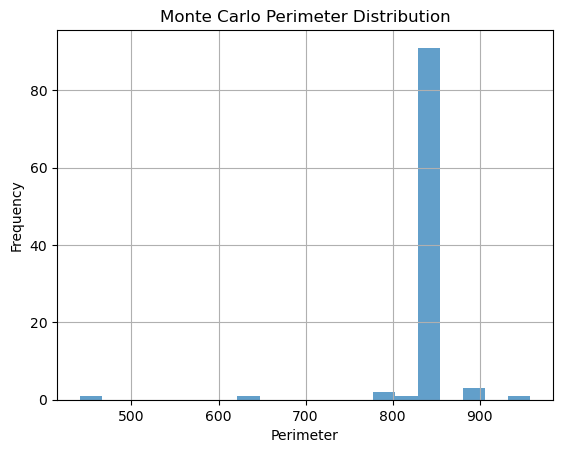

Estimated perimeter: 833.77 ± 47.61
[28.9764766  28.9764766  28.9764766  28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.9764766  28.9764766
 25.2997404  28.9764766  28.9764766  28.91096605 28.91096605 28.91096605
 28.9764766  28.91096605 28.9764766  28.9764766  28.97250694 28.9764766
 30.03070643 28.91096605 28.91096605 28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.9764766  28.11153088 28.9764766  28.90135979 28.91096605 28.9764766
 28.91096605 29.83363887 28.91096605 28.91096605 28.91096605 28.91096605
 28.9764766  28.91096605 30.95588507 28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.93016901 28.9764766  28.9764766  28.9764766  28.9764766  28.13776252
 28.91096605 28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.40030472 28.91096605 28.91096605 28.91096605 20.98584999 28.9764766
 28.9764766  28.91096605 

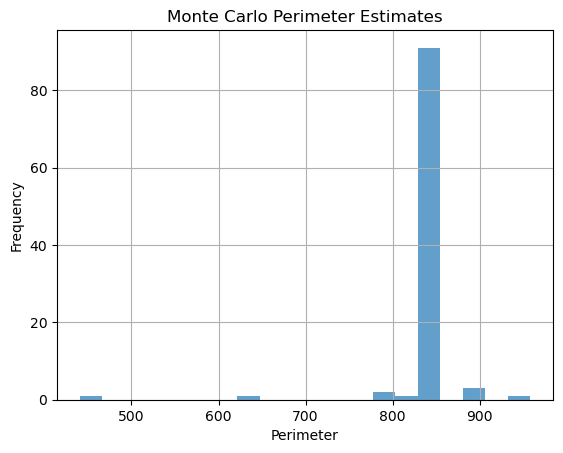

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import perimeter_crofton
from scipy.ndimage import shift
from skimage.util import random_noise

def monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8):
    perimeters = []
    for _ in range(n_iter):
        perturbed = image.copy()

        if 'shift' in perturb:
            dx, dy = np.random.uniform(-0.5, 0.5, size=2)
            perturbed = shift(perturbed, shift=(dy, dx), order=1, mode='nearest')

        if 'noise' in perturb:
            noisy = random_noise(perturbed, mode='gaussian', var=0.001)
            perturbed = (noisy > 0.5).astype(float)

        p = perimeter_crofton(perturbed, directions=directions)
        perimeters.append(p)

    perimeters = np.array(perimeters)
    mean_p = np.mean(perimeters)
    var_p = np.var(perimeters)
    std_p = np.std(perimeters)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(f"Variance: {var_p:.2f}, Mean: {mean_p:.2f}, Var/Mean ratio: {var_p/mean_p:.3f}")

    # Optional: plot histogram
    plt.hist(perimeters, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Distribution")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    return mean_p, std_p, perimeters

# Example usage
if __name__ == "__main__":
    from skimage.data import binary_blobs
    image = binary_blobs(length=128, blob_size_fraction=0.2, volume_fraction=0.3)

    mean_p, std_p, perim_samples = monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(np.sqrt((perim_samples)))

    # Plot distribution
    plt.hist(perim_samples, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Estimates")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

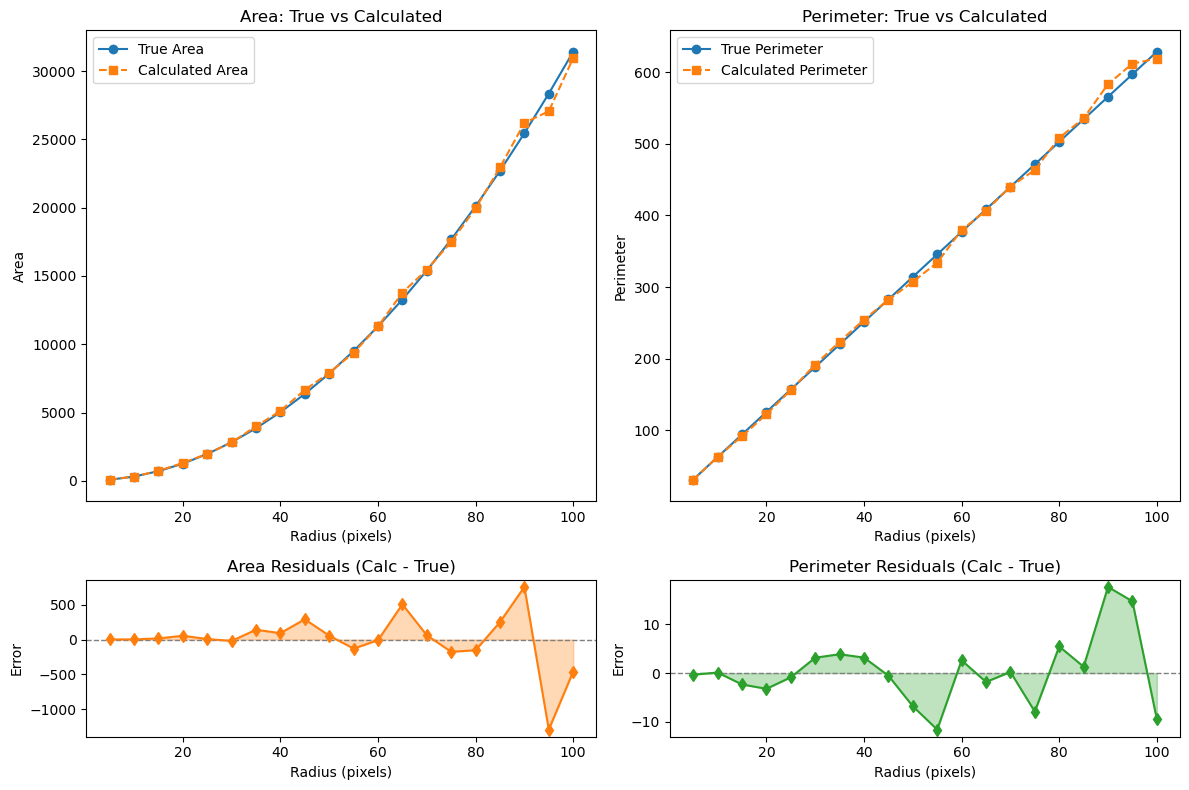

Average percentual variation (area): 2.03%
Average percentual variation (perimeter): 1.43%


In [13]:
from skimage.draw import disk
import numpy as np
import matplotlib.pyplot as plt 
from skimage.measure import perimeter_crofton

# Parameters
radii = np.arange(5, 51, 5)  # radii from 5 to 50 pixels
image_size = 128
areas_true = []
perims_true = []
areas_calc = []
perims_calc = []

for r in radii:
    img = np.zeros((image_size, image_size), dtype=float)
    rr, cc = disk((image_size // 2, image_size // 2), r, shape=img.shape)
    img[rr, cc] = 1.0

    # True values
    area_true = np.pi * r**2
    perim_true = 2 * np.pi * r

    # Calculated values
    area_calc = img.sum()
    perim_calc = perimeter_crofton(img, directions=8)

    areas_true.append(area_true)
    perims_true.append(perim_true)
    areas_calc.append(area_calc)
    perims_calc.append(perim_calc)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Example data (replace with your data)
radii = np.linspace(5, 100, 20)
areas_true = np.pi * radii**2
areas_calc = areas_true * (1 + np.random.normal(0, 0.02, len(radii)))
perims_true = 2 * np.pi * radii
perims_calc = perims_true * (1 + np.random.normal(0, 0.02, len(radii)))

# Prepare figure with GridSpec
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, height_ratios=[3, 1])

# Top left: Area comparison
ax_area = fig.add_subplot(gs[0, 0])
ax_area.plot(radii, areas_true, 'o-', label='True Area')
ax_area.plot(radii, areas_calc, 's--', label='Calculated Area')
ax_area.set_xlabel('Radius (pixels)')
ax_area.set_ylabel('Area')
ax_area.set_title('Area: True vs Calculated')
ax_area.legend()

# Top right: Perimeter comparison
ax_perim = fig.add_subplot(gs[0, 1])
ax_perim.plot(radii, perims_true, 'o-', label='True Perimeter')
ax_perim.plot(radii, perims_calc, 's--', label='Calculated Perimeter')
ax_perim.set_xlabel('Radius (pixels)')
ax_perim.set_ylabel('Perimeter')
ax_perim.set_title('Perimeter: True vs Calculated')
ax_perim.legend()

# Bottom left: Area residuals
area_errors = np.array(areas_calc) - np.array(areas_true)
ax_area_resid = fig.add_subplot(gs[1, 0])
ax_area_resid.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_area_resid.plot(radii, area_errors, 'd-', color='tab:orange')
ax_area_resid.fill_between(radii, area_errors, 0, color='tab:orange', alpha=0.3)
ax_area_resid.set_xlabel('Radius (pixels)')
ax_area_resid.set_ylabel('Error')
ax_area_resid.set_title('Area Residuals (Calc - True)')

# Bottom right: Perimeter residuals
perim_errors = np.array(perims_calc) - np.array(perims_true)
ax_perim_resid = fig.add_subplot(gs[1, 1])
ax_perim_resid.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_perim_resid.plot(radii, perim_errors, 'd-', color='tab:green')
ax_perim_resid.fill_between(radii, perim_errors, 0, color='tab:green', alpha=0.3)
ax_perim_resid.set_xlabel('Radius (pixels)')
ax_perim_resid.set_ylabel('Error')
ax_perim_resid.set_title('Perimeter Residuals (Calc - True)')

plt.tight_layout()
plt.show()

# Calculate average percentual variation for area and perimeter
area_percent_var = 100 * np.mean(np.abs(area_errors / areas_true))
perim_percent_var = 100 * np.mean(np.abs(perim_errors / perims_true))

print(f"Average percentual variation (area): {area_percent_var:.2f}%")
print(f"Average percentual variation (perimeter): {perim_percent_var:.2f}%")

In [42]:
area_percent_vars = []
perim_percent_vars = []

for _ in range(1000):
    areas_calc_run = areas_true * (1 + np.random.normal(0, 0.02, len(radii)))
    perims_calc_run = perims_true * (1 + np.random.normal(0, 0.02, len(radii)))
    area_errors_run = areas_calc_run - areas_true
    perim_errors_run = perims_calc_run - perims_true

    area_percent_var_run = 100 * np.mean(np.abs(area_errors_run / areas_true))
    perim_percent_var_run = 100 * np.mean(np.abs(perim_errors_run / perims_true))

    area_percent_vars.append(area_percent_var_run)
    perim_percent_vars.append(perim_percent_var_run)

print(f"Average percentual variation (area) over 1000 runs: {np.mean(area_percent_vars):.2f}%")
print(f"Average percentual variation (perimeter) over 1000 runs: {np.mean(perim_percent_vars):.2f}%")

Average percentual variation (area) over 1000 runs: 1.60%
Average percentual variation (perimeter) over 1000 runs: 1.60%
